# How many Americans were affected by the redistricting wars?

2025 and 2026 saw a wave of mid-cycle redistricting across the country. In ten states (Texas, California, Missouri, Ohio, North Carolina, Utah, Alabama, Louisiana, Tennessee, and Florida), new maps were put in place for the 120th Congress. In other states (like Virginia), redistricting was attempted but blocked by the courts. We'll focus here just on the ten states that saw redistricting.

The goal of this notebook is to figure out, after all the new maps were drawn, what fraction of Americans ended up in a new Congressional district.

Seems simple enough. But what counts as a "new" district? If a state simply renumbered all its districts without changing lines, everyone in that state would live in a "new" district under the simplest definition, even though nothing really would have really changed. Meanwhile, if a district swaps 1% of its area and population with another neighboring district, both districts are "new" in some sense, but really they're mostly the same. So what counts as "new" is in the eye of the beholder.

To get around this, we take two approaches here: we measure both the *nominal # of Americans in new districts*, and also the number *weighted by population overlap*. In other words, if you went from living in the 4th Congressional district to the 5th, you'd be counted under the first approach, regardless of how the district lines moved. Under the second approach, if less than (say) 75% of the original district population remained in place, then you'd count as living in a new district. We show how the top-line number changes as the threshold moves from 0% to 100%.

## Bottom Line Up Front
Under the first approach, about *10.9%* of Americans had their Congressional district change between 2024 and 2026. Under the second approach, with a threshold of 75%, the number is about *19.3%*. 

We'll go over why the second number is higher than the first below.

## AI Disclosure
Much of the code in this notebook was written with the use of an AI model (Sonnet 5). I've read through every line of code carefully, inspected the variables by hand, and reviewed the outputs, but cannot fully rule out hallucinations or bugs. If you encounter a bug or mistake, please open an issue on GitHub. None of the markdown cells were authored by AI.

## Preliminaries

In [1]:
import zipfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

pd.set_option('display.max_colwidth', None)

# Plot styling
# NOTE: I use dark mode for my notebooks; the plots will therefore look
# nicer if you use dark mode in your browser on GitHub.

CATEGORICAL = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4"]
INK = "#FFFFFF"
MUTED_INK = "#BBBBBB"
GRIDLINE = "#e1e0d9"

plt.rcParams.update({
    "figure.figsize":(8,4),
    "figure.facecolor": "#1a1b26",
    "axes.facecolor": "#1a1b26",
    "savefig.facecolor": "#1a1b26",
    "axes.edgecolor": MUTED_INK,
    "axes.labelcolor": MUTED_INK,
    "text.color": INK,
    "xtick.color": MUTED_INK,
    "ytick.color": MUTED_INK,
    "xtick.labelcolor": MUTED_INK,
    "ytick.labelcolor": MUTED_INK,
    "axes.titlecolor": INK,
    "legend.labelcolor": INK,
    "grid.color": GRIDLINE,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})


In [31]:
DATA_DIR = Path("data")

# FIPS code -> (postal abbreviation, full name) for the states redrawn in the 2025-2026 wars.
STATES = {
    "01": ("AL", "Alabama"),
    "06": ("CA", "California"),
    "12": ("FL", "Florida"),
    "22": ("LA", "Louisiana"),
    # "29": ("MO", "Missouri"), # It's unclear as of 9/9/2026 which maps Missouri will use
    "37": ("NC", "North Carolina"),
    "39": ("OH", "Ohio"),
    "47": ("TN", "Tennessee"),
    "48": ("TX", "Texas"),
    "49": ("UT", "Utah"),
}


In [32]:
# 2020 P.L. 94-171 field positions we need
# Geoheader: block-level rows only (SUMLEV == "750").
GEOHEADER_COLS = {"SUMLEV": 2, "LOGRECNO": 7, "GEOID": 9, "AREALAND": 84}
# Segment 1, field P0010001 = total population.
TOTAL_POP_COLS = {"LOGRECNO": 4, "TOTAL_POP": 5}
# Segment 2, field P0030001 = population 18 years and over (voting-age population).
VAP_COLS = {"LOGRECNO": 4, "VAP": 5}


In [33]:
def read_pl_file(zf: zipfile.ZipFile, member: str, col_positions: dict[str, int]) -> pd.DataFrame:
    """Reads selected columns of a pipe-delimited 2020 P.L. 94-171 file.

    Args:
        zf: Open zip archive containing the state's P.L. 94-171 files.
        member: Name of the file inside the archive to read.
        col_positions: Mapping of output column name to its 0-indexed position.

    Returns:
        DataFrame with the requested columns, read as strings.
    """
    with zf.open(member) as f:
        return pd.read_csv(
            f,
            sep="|",
            header=None,
            usecols=list(col_positions.values()),
            names=list(col_positions.keys()),
            dtype=str,
            encoding="latin-1",  # geoheader place names include non-UTF-8 bytes
        )


In [34]:
def load_state_blocks(fips: str, abbr: str) -> pd.DataFrame:
    """Loads block-level geography, population, and VAP for one state.

    Args:
        fips: Two-digit state FIPS code.
        abbr: Two-letter postal abbreviation, matching the P.L. zip file prefix.

    Returns:
        DataFrame with one row per census block: GEOID, STATE_FIPS, AREALAND, TOTAL_POP, VAP.
    """
    prefix = abbr.lower()
    with zipfile.ZipFile(DATA_DIR / f"{prefix}2020.pl.zip") as zf:
        geo = read_pl_file(zf, f"{prefix}geo2020.pl", GEOHEADER_COLS)
        geo = geo[geo["SUMLEV"] == "750"].drop(columns="SUMLEV")
        total_pop = read_pl_file(zf, f"{prefix}000012020.pl", TOTAL_POP_COLS)
        vap = read_pl_file(zf, f"{prefix}000022020.pl", VAP_COLS)

    blocks = geo.merge(total_pop, on="LOGRECNO").merge(vap, on="LOGRECNO")
    blocks["AREALAND"] = blocks["AREALAND"].astype("int64")
    blocks["TOTAL_POP"] = blocks["TOTAL_POP"].astype("int64")
    blocks["VAP"] = blocks["VAP"].astype("int64")
    blocks["STATE_FIPS"] = fips
    return blocks.drop(columns="LOGRECNO")


## Load data into Pandas DataFrames

In [35]:
blocks_df = pd.concat(
    [load_state_blocks(fips, abbr) for fips, (abbr, _) in tqdm(STATES.items(), desc="Loading population data")],
    ignore_index=True,
)
blocks_df.shape


Loading population data: 100%|##########| 9/9 [00:15<00:00,  1.73s/it]


(2671386, 5)


## Sanity checks
Let's make a couple plots to ensure that the data looks reasonable.

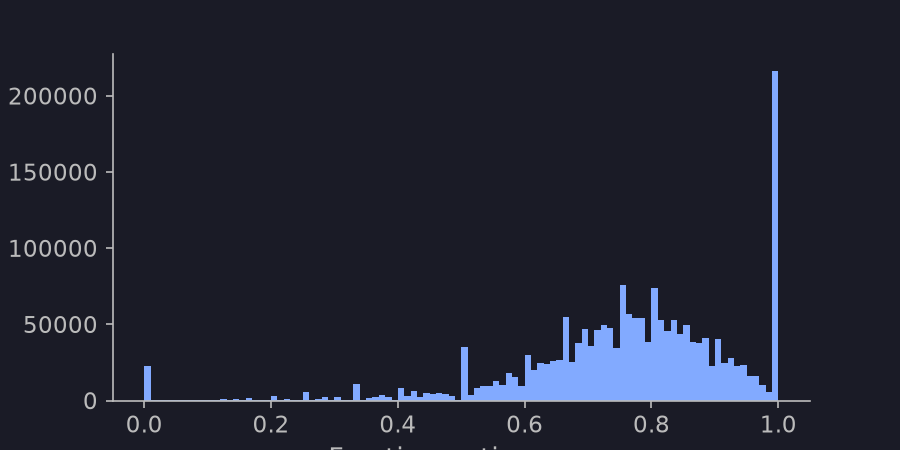

In [59]:
# Ensure VAP is <=100% of the block population
fig = plt.figure(figsize = [6,3])
plt.hist(blocks_df['VAP'] / blocks_df['TOTAL_POP'], bins = 100)
plt.ylabel('Count')
plt.xlabel('Fraction voting-age')
plt.show()

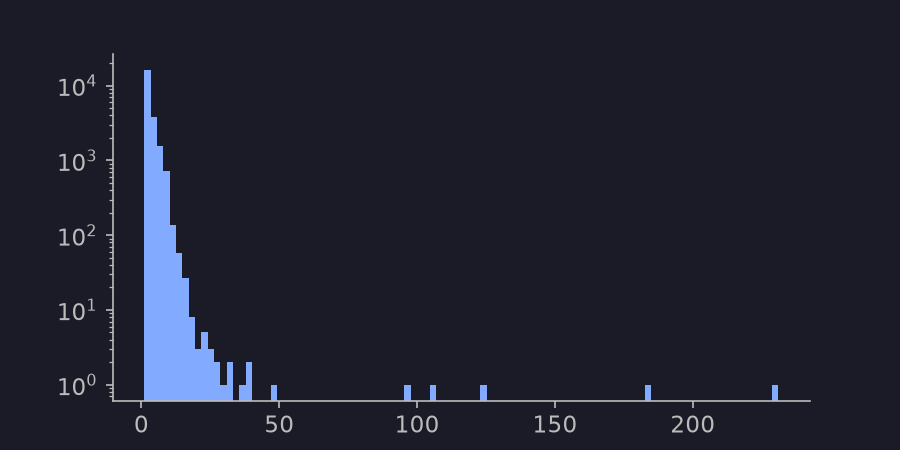

In [60]:
fig = plt.figure(figsize = [6,3])
all_young = blocks_df[np.logical_and(blocks_df['VAP'] == 0, blocks_df['TOTAL_POP'] > 0)]
plt.hist(all_young['TOTAL_POP'], bins = 100)
plt.yscale('log')
plt.show()

In [38]:
np.unique(blocks_df[np.logical_and(blocks_df['AREALAND'] == 0, blocks_df['TOTAL_POP']>0)].sort_values('TOTAL_POP')['STATE_FIPS'], return_counts=True)

(array(['01', '06', '12', '22', '37', '39', '47', '48', '49'], dtype=object), array([ 16,  71, 107,  24,  35,   8,  18,  41,   1]))


A couple oddities I noticed. Neither are of major concern:
- Some blocks are all below age 18. These are likely either juvenile detention facilities or statistical noise that the Census injects. The official Census [documentation](https://www2.census.gov/library/publications/decennial/2020/census-briefs/c2020br-08.pdf) actually calls out all-juvenile blocks as an artifact of their differential privacy program.
- 340 blocks have 0 land area but nonzero population. A plurality (107) are in Florida. This is likely due to irregularities with how the TIGER shapefiles measure water & land, especially in places where lots of people live near canals, lakes, and reservoirs (Florida has a lot of those). 

## Crosswalk old and new Congressional districts

This is actually fairly straightforward:

In [39]:
def load_cd_assignments(geoid_and_cd: pd.DataFrame, cd_column: str) -> pd.DataFrame:
    """Reduces a block assignment file to just GEOID and a renamed district column."""
    return geoid_and_cd[["GEOID", "CDFP"]].rename(columns={"CDFP": cd_column})


In [40]:
new_cd_df = pd.concat(
    [
        load_cd_assignments(pd.read_csv(DATA_DIR / f"CD120_{fips}.txt", dtype=str), "new_cd")
        for fips in STATES
    ],
    ignore_index=True,
)
print(new_cd_df.shape)


(2671386, 2)


In [41]:
with zipfile.ZipFile(DATA_DIR / "cd119.zip") as zf:
    with zf.open("NationalCD119.txt") as f:
        national_cd119 = pd.read_csv(f, dtype=str)

old_cd_df = load_cd_assignments(national_cd119, "old_cd")
old_cd_df = old_cd_df[old_cd_df["GEOID"].str[:2].isin(STATES)]
print(old_cd_df.shape)


(2671386, 2)


We have exactly matching numbers of blocks between the old and new maps, which is nice to see. Now we just need to match them by their GEOIDs.

In [42]:
crosswalk = blocks_df.merge(old_cd_df, on="GEOID", how="inner").merge(new_cd_df, on="GEOID", how="inner")
assert len(crosswalk) == len(blocks_df), "some blocks are missing an old or new district assignment"

crosswalk["STATE_ABBR"] = crosswalk["STATE_FIPS"].map(lambda f: STATES[f][0])
crosswalk["BLOCK_COUNT"] = 1
crosswalk.shape


(2671386, 9)


Merging the old and new maps into a single DataFrame lost no blocks, so every block has a previous district and a new district.

## Approach 1: Nominal changes
Let's add up how many nominal changes we see by state ("nominal change" means the number of the Congressional district changed - it doesn't say anything about the new district lines or the old).

In [43]:
def summarize_change(df: pd.DataFrame, changed_column: str) -> pd.DataFrame:
    """Summarizes population and VAP affected by district change, by state.

    Args:
        df: Block-level crosswalk with population, VAP, and a boolean change indicator.
        changed_column: Name of the boolean column marking a block as changed.

    Returns:
        One row per state with the share of population and VAP in changed blocks.
    """
    changed = df[df[changed_column]]
    by_state = df.groupby("STATE_ABBR")[["TOTAL_POP", "VAP"]].sum()
    changed_by_state = changed.groupby("STATE_ABBR")[["TOTAL_POP", "VAP"]].sum()
    summary = by_state.join(changed_by_state, rsuffix="_CHANGED").fillna(0)
    summary["POP_PCT_CHANGED"] = 100 * summary["TOTAL_POP_CHANGED"] / summary["TOTAL_POP"]
    summary["VAP_PCT_CHANGED"] = 100 * summary["VAP_CHANGED"] / summary["VAP"]
    return summary.sort_values("POP_PCT_CHANGED", ascending=False)


In [44]:
def plot_state_bars(summary: pd.DataFrame, column: str, title: str, ax=None):
    """Draws a single-series horizontal bar chart of one metric, one bar per state."""
    ax = ax or plt.gca()
    ordered = summary.sort_values(column)
    ax.barh(ordered.index, ordered[column], color=CATEGORICAL[0])
    ax.set_xlabel("% of population")
    ax.set_title(title, color=MUTED_INK)
    ax.grid(axis="x", linewidth=0.5, ls= '--')
    ax.set_axisbelow(True)
    return ax


In [45]:
crosswalk['renumbered'] = crosswalk['new_cd'] != crosswalk['old_cd']

In [46]:

pd.set_option('display.max_colwidth', 20)
pd.set_option('display.max_columns', 10)
pd.set_option('display.width', 200)

naive_summary = summarize_change(crosswalk, "renumbered")
print(naive_summary)


            TOTAL_POP       VAP  TOTAL_POP_CHANGED  VAP_CHANGED  POP_PCT_CHANGED  VAP_PCT_CHANGED
STATE_ABBR                                                                                       
UT            3271616   2324051            2260487      1613920        69.093897        69.444259
TX           29145505  21866700           10448258      7800839        35.848609        35.674514
TN            6910840   5384473            2400948      1857669        34.741768        34.500479
LA            4657757   3570548            1497479      1143968        32.150217        32.039004
FL           21538187  17339232            6265306      5022925        29.089291        28.968555
CA           39538223  30827105            9214062      7165284        23.304188        23.243454
AL            5024279   3917166             660496       513247        13.146085        13.102508
OH           11799448   9207562            1478290      1143440        12.528467        12.418488
NC           1043938

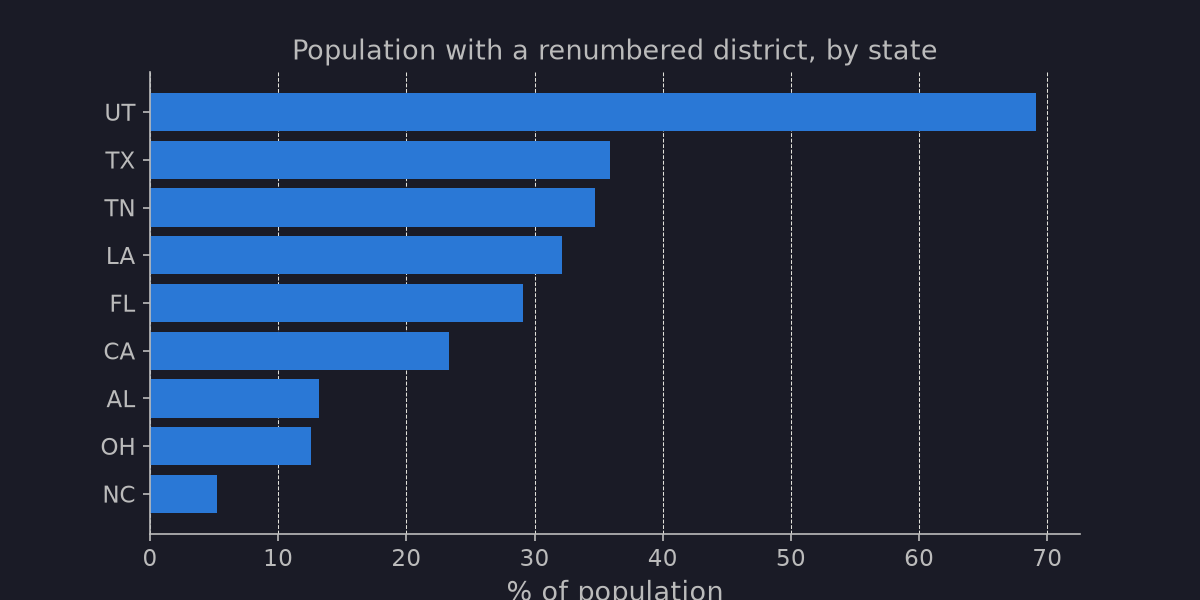

In [47]:
plot_state_bars(naive_summary, "POP_PCT_CHANGED", "Population with a renumbered district, by state")
plt.show()


Looks like Utah leads the pack in nominal redistricting. No surprise - looking at a map on [Wikipedia](https://en.wikipedia.org/wiki/2025%E2%80%932026_United_States_redistricting#Utah), it's clear that the majority of the population is in a new district.

North Carolina is at the bottom, also matching our intuition from looking at the [map](https://en.wikipedia.org/wiki/2025%E2%80%932026_United_States_redistricting#North_Carolina) (only districts 1 & 3 changed at all).

## Approach 2: threshold matching

This is where things get somewhat more interesting. Here's what we'll do: for each *old* district, find the *new* district that inherited the largest share of its population. Then identify the old and new districts with one another where possible.
    - For example, imagine that old District 1 gets broken up and 70% of its population is now in a new District 3, and 30% of its population is in a new District 8. If we set our threshold at 50%, then we identify old District 1 with new District 3. 
    - In this example, the 30% of folks who now live in District 8 are considered to live in a new district.

In [48]:
def compute_overlap_shares(df: pd.DataFrame, weight_column: str) -> pd.DataFrame:
    """Computes, for every (old district, new district) pair, the share of the old district's
    weight that ended up in that new district.

    Args:
        df: Block-level crosswalk.
        weight_column: Column to weight by - e.g. TOTAL_POP, AREALAND, or BLOCK_COUNT.

    Returns:
        DataFrame indexed by (STATE_FIPS, old_cd, new_cd) with a 'share' column.
    """
    overlap = df.groupby(["STATE_FIPS", "old_cd", "new_cd"])[weight_column].sum()
    old_totals = df.groupby(["STATE_FIPS", "old_cd"])[weight_column].sum()
    return (overlap / old_totals).rename("share").reset_index()


In [49]:
def match_old_to_new(overlap_shares: pd.DataFrame, threshold: float) -> dict:
    """Matches each old district to its dominant new district, if that dominance clears a threshold.

    Args:
        overlap_shares: Output of compute_overlap_shares.
        threshold: Minimum share of the old district's weight required to call it a match.

    Returns:
        Mapping from (STATE_FIPS, old_cd) to the matched new_cd, or None if no match clears the threshold.
    """
    best = overlap_shares.loc[overlap_shares.groupby(["STATE_FIPS", "old_cd"])["share"].idxmax()]
    return {
        (row.STATE_FIPS, row.old_cd): (row.new_cd if row.share >= threshold else None)
        for row in best.itertuples()
    }


In [50]:
def flag_real_change(df: pd.DataFrame, match_map: dict) -> pd.Series:
    """Flags blocks that ended up outside their old district's matched new district."""
    matched_new_cd = df.set_index(["STATE_FIPS", "old_cd"]).index.map(match_map.get)
    return (df["new_cd"].to_numpy() != matched_new_cd).astype(bool)


In [51]:
DEFAULT_WEIGHT = "TOTAL_POP"
DEFAULT_THRESHOLD = 0.75

overlap_shares = compute_overlap_shares(crosswalk, DEFAULT_WEIGHT)

overlap_shares_ut = overlap_shares[overlap_shares['STATE_FIPS'] == '49']
match_map = match_old_to_new(overlap_shares, DEFAULT_THRESHOLD)
crosswalk["really_changed"] = flag_real_change(crosswalk, match_map)
threshold_summary = summarize_change(crosswalk, "really_changed")


In [52]:
threshold_summary


            TOTAL_POP       VAP  TOTAL_POP_CHANGED  VAP_CHANGED  POP_PCT_CHANGED  VAP_PCT_CHANGED
STATE_ABBR                                                                                       
UT            3271616   2324051            2582082      1842171        78.923749        79.265515
TX           29145505  21866700           20622323     15473427        70.756444        70.762516
TN            6910840   5384473            4652819      3587620        67.326389        66.628990
LA            4657757   3570548            2153127      1647308        46.226692        46.135999
FL           21538187  17339232            9557726      7615208        44.375722        43.918946
CA           39538223  30827105           16672428     13032617        42.167874        42.276487
AL            5024279   3917166            1529806      1191083        30.448269        30.406753
OH           11799448   9207562            2047948      1579210        17.356303        17.151229
NC           1043938

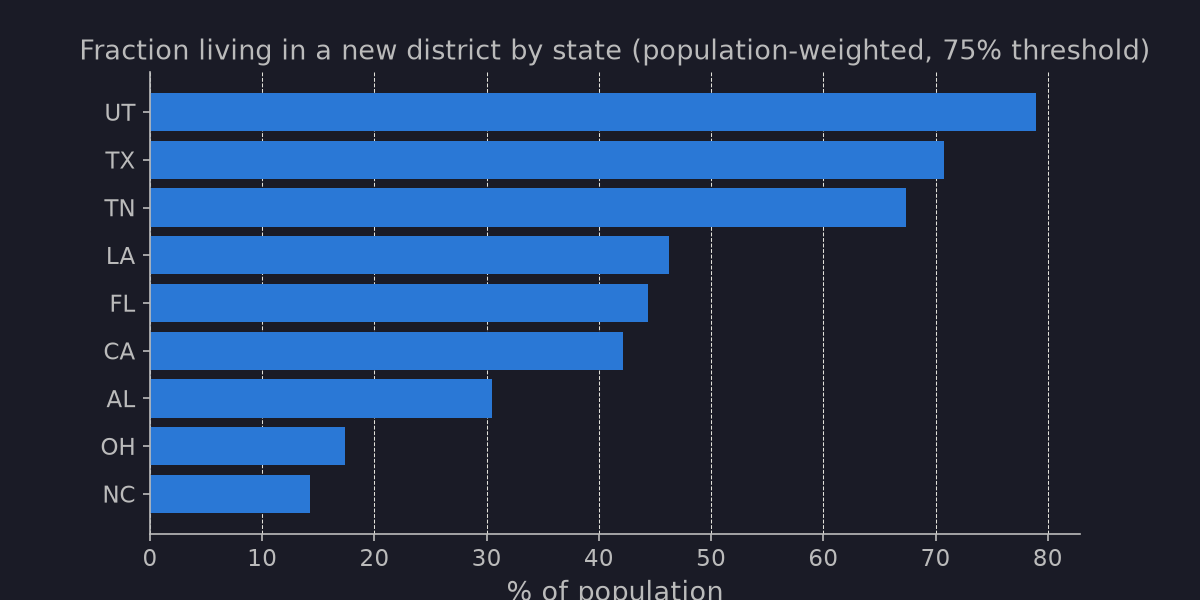

In [53]:
plot_state_bars(
    threshold_summary,
    "POP_PCT_CHANGED",
    f"Fraction living in a new district by state (population-weighted, {DEFAULT_THRESHOLD:.0%} threshold)",
)
plt.show()


Utah still leads the pack; North Carolina stays at the bottom (although this will change if you set the threshold at different values).

## Comparing Approach 1 and Approach 2

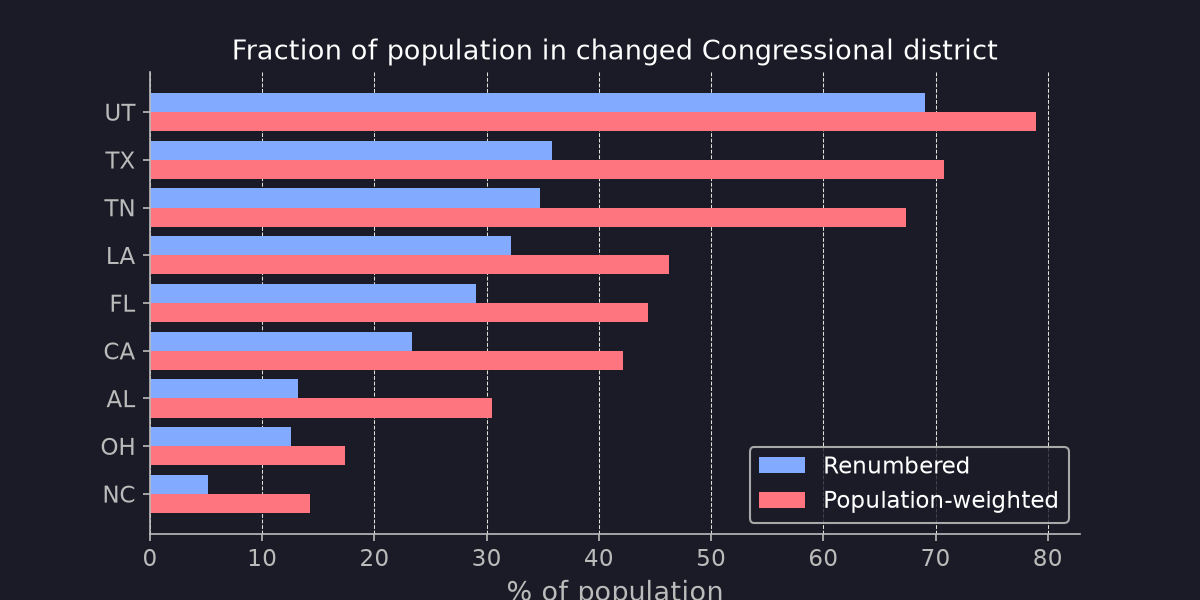

In [54]:
comparison = pd.DataFrame({
    "Renumbered (naive)": naive_summary["POP_PCT_CHANGED"],
    "Really changed (threshold)": threshold_summary["POP_PCT_CHANGED"],
}).sort_values("Renumbered (naive)")

fig, ax = plt.subplots()
y = range(len(comparison))
ax.barh([i + 0.2 for i in y], comparison["Renumbered (naive)"], height=0.4, label="Renumbered")
ax.barh([i - 0.2 for i in y], comparison["Really changed (threshold)"], height=0.4, label="Population-weighted")
ax.set_yticks(list(y), comparison.index)
ax.set_xlabel("% of population")
ax.set_title("Fraction of population in changed Congressional district")
ax.legend(frameon=True)
ax.grid(axis="x", linewidth=0.5, ls = '--')
ax.set_axisbelow(True)
plt.show()


## Discussion
Why are the population-weighted numbers higher in all cases than the renumbered ones?

It's easiest to see in the North Carolina case, which only moved people between two districts (1 and 3). In both districts, around 65% of the original population stayed in their old numbered district, while about 35% moved from 1 to 3 or 3 to 1. So, the *new* district 1 is made up of 65% *old* district 1 people and 35% *old* district 3 people. 

Remember how our method works: we take each *old* district and look where the biggest fraction of its population went. So we look at *old* district 1, and find that the biggest fraction (65%) are in the *new* district 1. But 65% is less than our threshold (75%), so we consider the *new* district 1 to be distinct enough that everyone in it has moved districts. That means two entire congressional districts (1 and 3) out of a total of fourteen have been moved. Two divided by 14 is about 14.3%, which is right where the red bar appears on the chart.

Under Approach 1, only the 35% of districts 1 and 3 would have counted as moving from one district to another. So, 70% equivalent of one district out of fourteen is `0.7/14=5%`, right where the blue bar is on the chart. That example encapsulates why the blue bars all fall below their red counterparts. 

Now look at Utah, at the top of the chart. Instead of just swapping a fraction of two districts back and forth, Utah decided to redraw almost all its lines. About 84% of the population of *old* district 1 went to *new* district 2, but *old* districts 2, 3, and 4 got broken up significantly: less than half of the population in any of those districts stayed together in any *new* district. That means that a much higher fraction of people ended up in a different district than they were before, measured by population. 

The other states, of course, all fall in between.

## Results
Now let's get to the main event, the fraction of all Americans who ended up in a new district:

In [55]:
# As a percentage of the US population:
TOTAL_US_POPULATION_2020=331_449_281
print(f'Approach 1: {naive_summary['TOTAL_POP_CHANGED'].sum() / TOTAL_US_POPULATION_2020 * 100 :.2f}%')
print(f'Approach 2: {threshold_summary["TOTAL_POP_CHANGED"].sum() / TOTAL_US_POPULATION_2020 * 100 :.2f}%')


Approach 1: 10.49%
Approach 2: 18.50%


In [56]:
# As a percentage of the populations in the 10 states that redistricted:
TOTAL_REDISTRICTED_STATE_POPULATION_2020=naive_summary['TOTAL_POP'].sum()
print(f'Approach 1: {naive_summary['TOTAL_POP_CHANGED'].sum() / TOTAL_REDISTRICTED_STATE_POPULATION_2020 * 100 :.2f}%')
print(f'Approach 2: {threshold_summary["TOTAL_POP_CHANGED"].sum() / TOTAL_REDISTRICTED_STATE_POPULATION_2020 * 100 :.2f}%')

Approach 1: 26.28%
Approach 2: 46.33%


## How sensitive is the threshold?
75% was our best estimate of what is reasonable to consider a continuity in population. But you might have your own definition - 50%, or 90%, or anything else. Let's see how the top-line number changes as the population threshold goes from 0% to 100%:

In [57]:
THRESHOLD_GRID = np.linspace(0., 1.0, 20)

sensitivity_rows = []
for threshold in tqdm(THRESHOLD_GRID):
    match_map = match_old_to_new(overlap_shares, threshold)
    changed = flag_real_change(crosswalk, match_map)
    summary = summarize_change(crosswalk.assign(_changed=changed), "_changed")
    for state, row in summary.iterrows():
        sensitivity_rows.append({"STATE_ABBR": state, "threshold": threshold, "pct_changed": row["POP_PCT_CHANGED"], "TOTAL_POP_CHANGED": row['TOTAL_POP_CHANGED']})

sensitivity = pd.DataFrame(sensitivity_rows)
grouped_sensitivity = sensitivity.groupby('threshold')['TOTAL_POP_CHANGED'].sum() / TOTAL_US_POPULATION_2020


100%|##########| 20/20 [00:14<00:00,  1.37it/s]


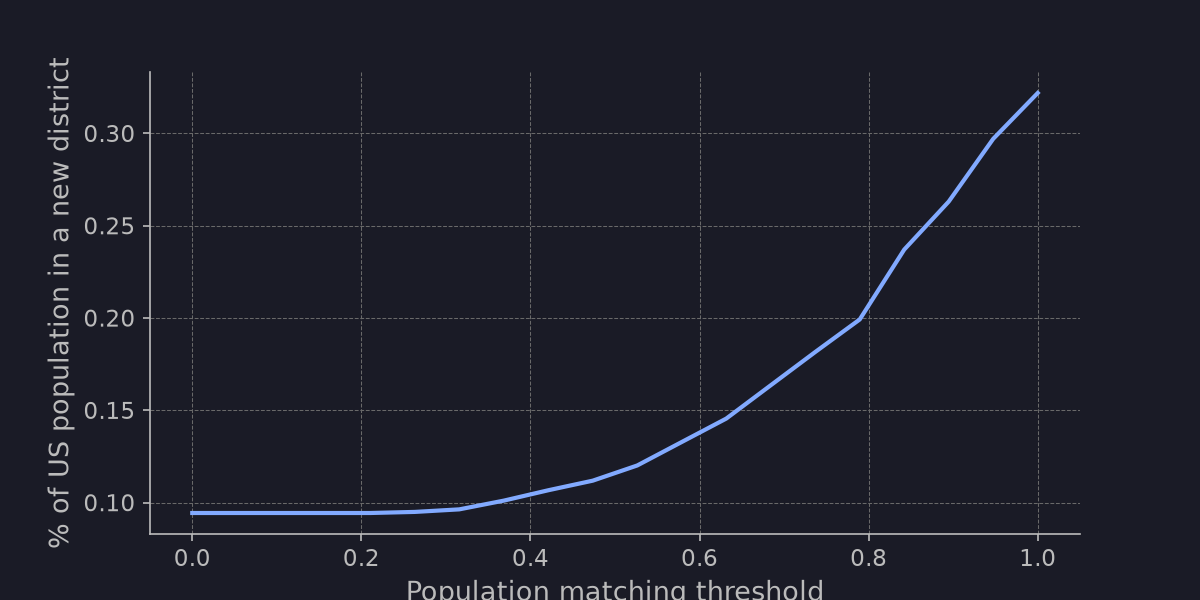

In [58]:
fig, axes = plt.subplots()
ax = plt.gca()
ax.plot(THRESHOLD_GRID,grouped_sensitivity.values, linewidth=2)
ax.set_xlabel("Population matching threshold")
ax.grid(linewidth=0.5, ls = '--', c = 'dimgray')
ax.set_axisbelow(True)
axes.set_ylabel("% of US population in a new district")
plt.show()


The fraction of the US population that is in a "new" district rises smoothly from about 10% to about 35% as you increase the threshold.
Interestingly, at the low end, the 10% is very close to (although slightly less than) the 10.9% we calculated from Approach 1. That seems to be just a coincidence.

Why doesn't the graph go to zero at a threshold of 0%? Because we mandated that each *old* district can map on to at most 1 new district. You can't have continuity between many old districts simultaneously - that wouldn't make sense! In our North Carolina example, you can't say that *new* District 1 is a continuity of *old* district 3 and *old* district 1. That's not how continuity works. No matter how you slice it in North Carolina, at least 35% of the folks in those districts were moved. And the same holds in the other states as well. 